# Two moons with changing noise

In [1]:
import torch
import numpy as np
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import two_moon_sim


torch_device = "cpu"
torch.set_default_device(torch_device)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Model

This notebook will demonstrate estimations of the two moons model with changing noise that depends on an extra parameter $n$. Suppose the posterior evaluated at the origin $x = (0, 0)$ of the "data" will resemble two crescent moons. The forward process is a noisy non-linear transformation on a 2D plane:

$$
\begin{align*}
x_1 &= -|\theta_1 + \theta_2|/\sqrt{2} + r \cos(\alpha) + 0.25 + \epsilon_1\\
x_2 &= (-\theta_1 + \theta_2)/\sqrt{2} + r\sin{\alpha} + \epsilon_2
\end{align*}
$$

with $x = (x_1, x_2)$ playing the role of "observables" (data to be learned from), $\alpha \sim \text{Uniform}(-\pi/2, \pi/2)$, and $r \sim \text{N}(0.1, 0.01^2)$ being latent variables creating noise in the data, and $\theta = (\theta_1, \theta_2)$ being the parameters that we will later seek to infer from new $x$.

And we have
$$
\epsilon_1, \epsilon_2 \sim \text{N}(0, \frac{1}{n})
$$
to mimic central limit theorm.

We set their priors to
$$
\begin{align*}
\theta_1, \theta_2 &\sim \text{Uniform}(-1, 1)\\
n &\sim \text{Uniform}(100, 10000).
\end{align*}
$$

In [2]:
def two_moons_npe_c(
    simulation_budget, seed, prior, x_obs, simulator, num_posterior_samples=1000
):
    prior, num_parameters, prior_returns_numpy = process_prior(prior)
    simulator = process_simulator(simulator, prior, prior_returns_numpy)
    check_sbi_inputs(simulator, prior)

    inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)

    learning_rate = 0.0005  # default value

    torch.manual_seed(seed)
    np.random.seed(seed)

    theta, x = simulate_for_sbi(
        simulator=simulator, proposal=prior, num_simulations=simulation_budget
    )

    density_estimator = inference.append_simulations(theta, x).train(
        max_num_epochs=100, learning_rate=learning_rate
    )
    posterior = inference.build_posterior(density_estimator).set_default_x(x_obs)

    theta_trained = posterior.sample((num_posterior_samples,), x=x_obs)
    theta_trained = theta_trained.reshape((num_posterior_samples, 3))

    return theta_trained.cpu().numpy()

**We only takes $(x_1, x_2)$ as summary statistics**

In [3]:
post_1order = two_moons_npe_c(
    simulation_budget=5000,
    seed=1,
    prior=two_moon_sim.prior_torch,
    x_obs=two_moon_sim.x_o,
    simulator=two_moon_sim.simulator_torch,
    num_posterior_samples=1000
)

100%|██████████| 5000/5000 [00:00<00:00, 8395.97it/s]


 Training neural network. Epochs trained: 101

  0%|          | 0/1000 [00:00<?, ?it/s]c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\torch\utils\_device.py:106: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2196.)
  return func(*args, **kwargs)
1090it [00:00, 15998.37it/s]            


In [4]:
post_1order

array([[ 2.7908149e-01,  1.5841174e-01,  3.2825503e+03],
       [-2.3895186e-01, -2.2949848e-01,  7.0527988e+03],
       [ 2.8271192e-01,  1.6644625e-01,  4.5717061e+03],
       ...,
       [-2.4072348e-01, -2.4214861e-01,  7.4439224e+03],
       [-1.5940885e-01, -2.2798219e-01,  1.8559827e+03],
       [ 2.0950992e-01,  2.8665575e-01,  9.3084678e+03]],
      shape=(1000, 3), dtype=float32)

**We take $(x_1, x_2, x_1^2, x_2^2)$ as summary statistics**

In [5]:
post_2order = two_moons_npe_c(
    simulation_budget=5000,
    seed=1,
    prior=two_moon_sim.prior_torch,
    x_obs=two_moon_sim.x_o_var,
    simulator=two_moon_sim.simulator_torch_var,
    num_posterior_samples=1000
)

100%|██████████| 5000/5000 [00:00<00:00, 7451.43it/s]


 Neural network successfully converged after 86 epochs.

1090it [00:00, 30037.46it/s]            


In [6]:
post_2order

array([[ 2.0625024e-01,  2.6760733e-01,  5.0633042e+03],
       [ 2.6861036e-01,  1.4124642e-01,  8.9856354e+02],
       [-2.6168159e-01, -1.5878880e-01,  5.6596655e+03],
       ...,
       [ 1.7187276e-01,  2.6170236e-01,  5.7004922e+03],
       [-1.7012148e-01, -2.5650796e-01,  1.2422013e+03],
       [-2.8408292e-01, -1.3837931e-01,  3.5629031e+02]],
      shape=(1000, 3), dtype=float32)

In [7]:
import matplotlib.pyplot as plt

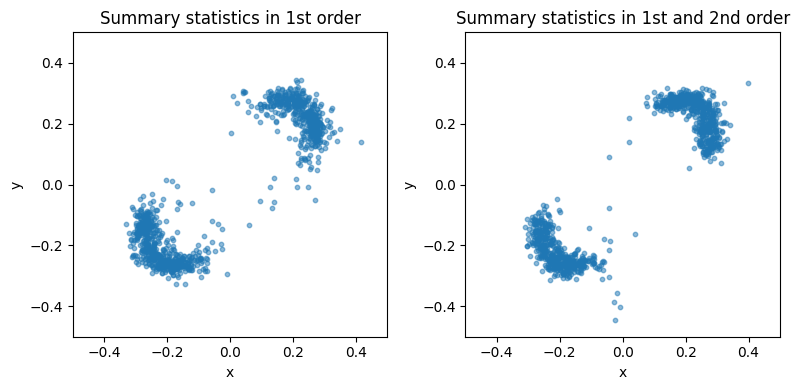

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].scatter(post_1order[:, 0], post_1order[:, 1], alpha=0.5, s=10)
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('Summary statistics in 1st order')
axs[0].set_xlim([-0.5, 0.5])
axs[0].set_ylim([-0.5, 0.5])

axs[1].scatter(post_2order[:, 0], post_2order[:, 1], alpha=0.5, s=10)
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].set_title('Summary statistics in 1st and 2nd order')
axs[1].set_xlim([-0.5, 0.5])
axs[1].set_ylim([-0.5, 0.5])

plt.tight_layout()
plt.show()